Decode Labs Project 4

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset_for_Data_Analytics.csv")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [4]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [5]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day_name()

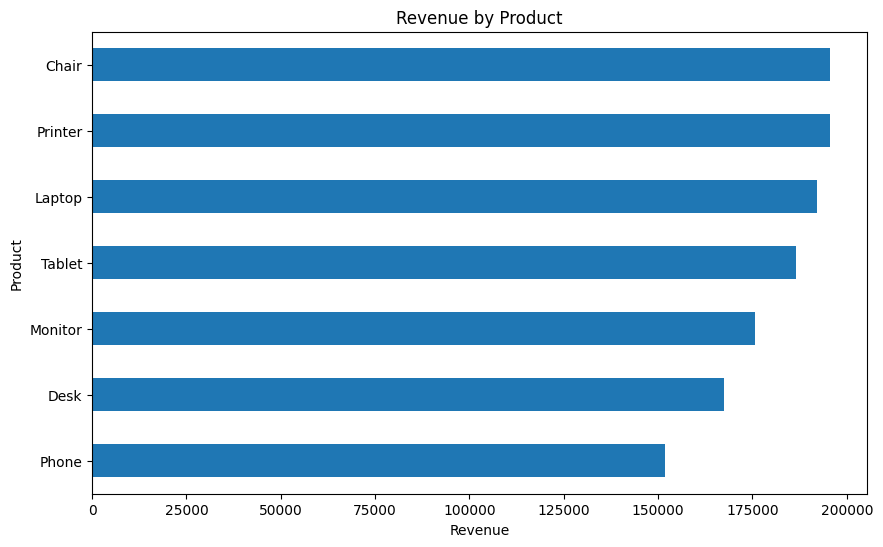

In [12]:
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values()

plt.figure(figsize=(10,6))
product_revenue.plot(kind='barh')

plt.title('Revenue by Product')
plt.xlabel('Revenue')
plt.show()

Insight-Chair generated the highest revenue, while Phone generated the lowest revenue among all products.
Office-related products such as Chairs, Printers, and Laptops contribute the majority of overall sales revenue.

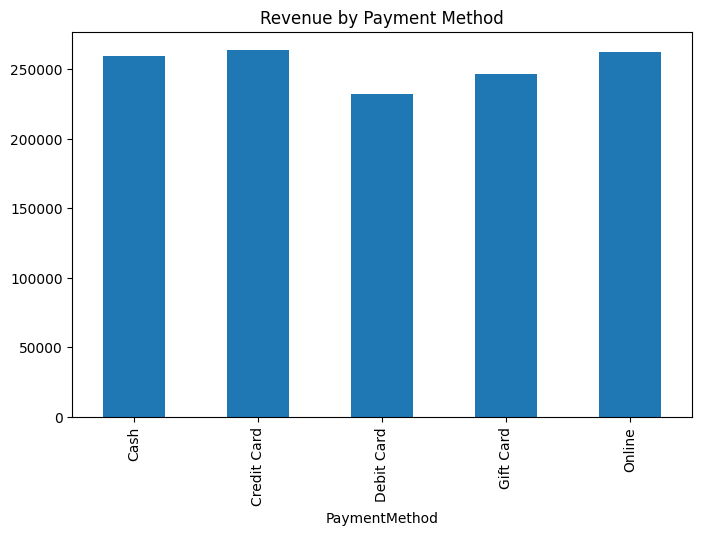

In [13]:
payment_revenue = df.groupby('PaymentMethod')['TotalPrice'].sum()

plt.figure(figsize=(8,5))
payment_revenue.plot(kind='bar')

plt.title('Revenue by Payment Method')
plt.show()

Insight-Credit Card and Online payments generated the highest revenue, indicating they are the most preferred payment methods among customers.
Debit Card contributed the lowest revenue, suggesting lower customer usage compared to other payment options

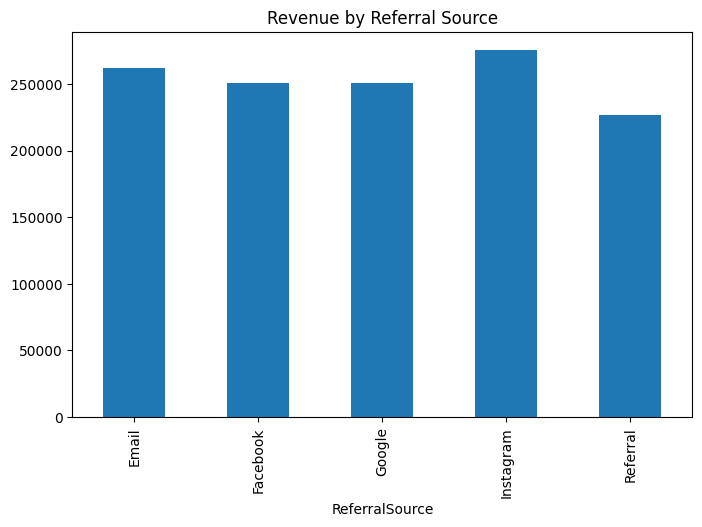

In [14]:
referral_revenue = df.groupby('ReferralSource')['TotalPrice'].sum()

plt.figure(figsize=(8,5))
referral_revenue.plot(kind='bar')

plt.title('Revenue by Referral Source')
plt.show()

Insight-Instagram generated the highest revenue among all referral sources, making it the most effective marketing channel for driving sales.
Referral contributed the lowest revenue, indicating that social media and digital marketing channels perform better than word-of-mouth referrals.

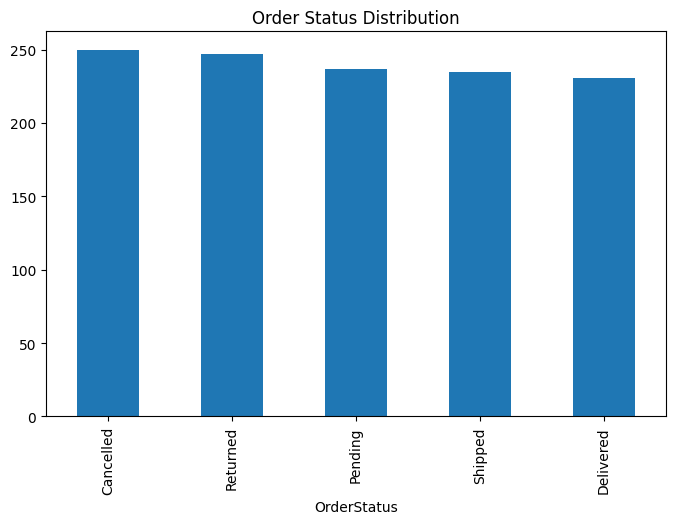

In [15]:
status = df['OrderStatus'].value_counts()

plt.figure(figsize=(8,5))
status.plot(kind='bar')

plt.title('Order Status Distribution')
plt.show()

Insight-Cancelled orders have the highest count, while Delivered orders have the lowest count, indicating potential issues in the order fulfillment process.
The distribution of order statuses is relatively balanced, suggesting that orders are spread across different stages rather than being concentrated in successful deliveries.

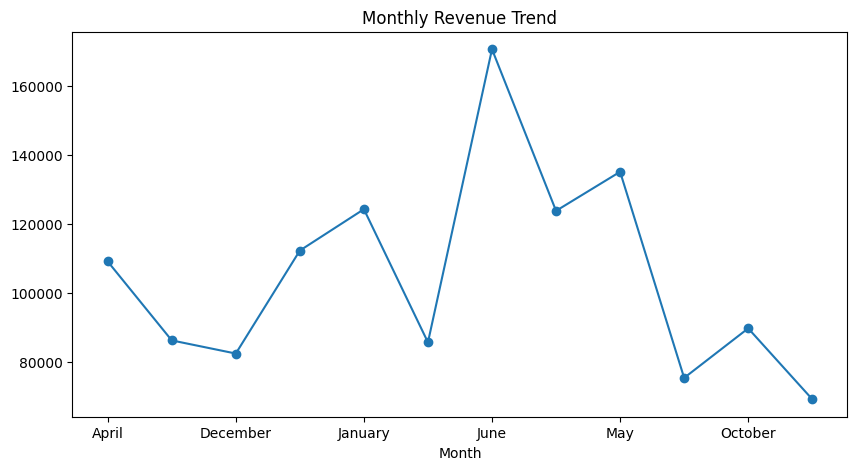

In [16]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.show()

Insight-Revenue reached its highest point in June, indicating a strong sales period and increased customer demand during that month.
Revenue declined significantly in the later months, with the lowest revenue recorded around November, suggesting seasonal fluctuations in sales performance.

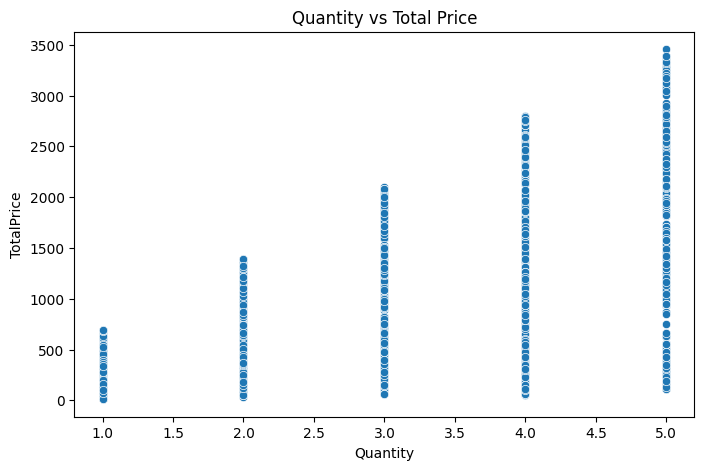

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Quantity',
    y='TotalPrice',
    data=df
)

plt.title('Quantity vs Total Price')
plt.show()

Insight-There is a clear positive relationship between Quantity and Total Price, as orders with higher quantities generally result in higher transaction values.
Customers purchasing 4–5 units contribute the highest revenue, indicating that larger order sizes have a significant impact on overall sales performance.

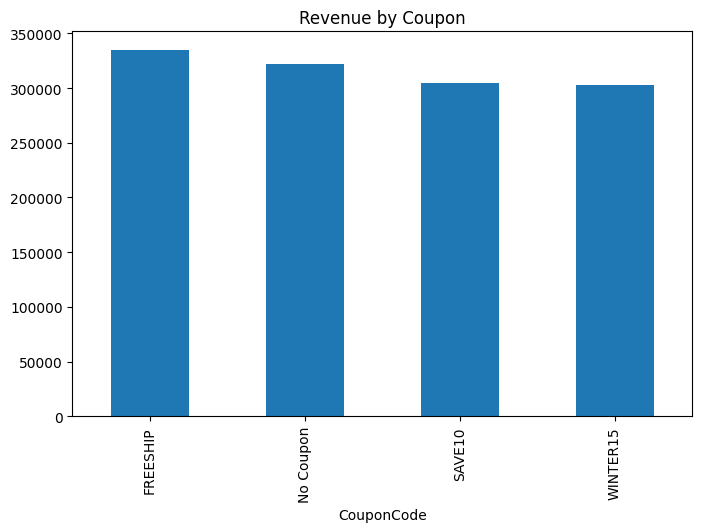

In [18]:
coupon = df.groupby('CouponCode')['TotalPrice'].sum()

plt.figure(figsize=(8,5))
coupon.plot(kind='bar')

plt.title('Revenue by Coupon')
plt.show()

Insight-The FREESHIP coupon generated the highest revenue, indicating that free shipping offers are highly effective in encouraging customer purchases.
Revenue from customers using No Coupon is also significant, suggesting that many customers are willing to purchase without promotional discounts.

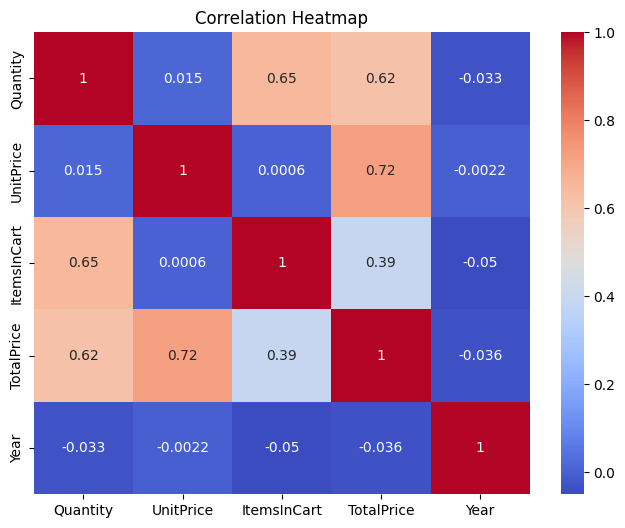

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

TotalPrice has a strong positive correlation with UnitPrice (0.72) and Quantity (0.62), indicating that higher-priced products and larger order quantities contribute significantly to revenue.
ItemsInCart also shows a moderate positive correlation with TotalPrice (0.39), while Year has almost no correlation with other variables, suggesting that sales performance is driven more by customer purchasing behavior than by time.

This project analyzed 1,200 e-commerce transactions using Python, Pandas, Matplotlib, and Seaborn. Through visualization and exploratory data analysis, key business insights were uncovered regarding revenue generation, customer behavior, payment preferences, marketing channels, and operational performance.